# Hybrid TPU + GDDR6-AiM Design-Space Sweep

Two independent one-variable-at-a-time sweeps on the hybrid TPU + AiM
architecture, keeping the TPU side unchanged:

1. **Buffer-size sweep** — vary the AiM `GlobalBuffer` with PU fanout held at 16 × 16.
2. **PU-fanout sweep** — vary the AiM `PU_Array` fanout with buffer held at 2 KB.

For each config we record total chip area, workload energy, and workload latency,
then compare against `tpu_only.yaml` and the canonical `tpu_aim_hybrid.yaml` baselines.

Workload: `gpt3_6.7B_kv_cache.yaml` (8192 prompt tokens, batch 1).

> Each sweep point re-runs the mapper (~30–60 s). Results are cached to
> `buffer_sweep.csv` and `fanout_sweep.csv`, so interrupts are recoverable.

In [2]:
import contextlib
import io
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import accelforge as af

EXAMPLES = Path("../examples")
ARCH = EXAMPLES / "arches" / "tpu_aim_hybrid_sweep.yaml"
WORKLOAD = EXAMPLES / "workloads" / "gpt3_6.7B_kv_cache.yaml"
BUFFER_CSV = Path("buffer_sweep.csv")
FANOUT_CSV = Path("fanout_sweep.csv")

BATCH_SIZE = 1
N_TOKENS = 8192

# Buffer sweep (fanout held fixed)
BUFFER_KBS = [1, 2, 4, 8, 16]
FIXED_FANOUT_FOR_BUFFER_SWEEP = 16

# PU-fanout sweep (buffer held fixed)
PU_FANOUTS = [8, 12, 16, 24, 32]
FIXED_BUF_FOR_FANOUT_SWEEP = 2


def pick_edp_best(energies, latencies):
    """Return (energy, latency) minimizing energy*latency over a Pareto set."""
    if not isinstance(energies, list):
        return energies, latencies
    idx = min(range(len(energies)), key=lambda i: energies[i] * latencies[i])
    return energies[idx], latencies[idx]


def evaluate_config(buffer_kb: int, pu_fanout: int) -> dict:
    """Compute total/per-component area + EDP-best energy/latency for one point."""
    params = {
        "BATCH_SIZE": BATCH_SIZE,
        "N_TOKENS": N_TOKENS,
        "AIM_BUFFER_KB": buffer_kb,
        "AIM_PU_FANOUT": pu_fanout,
    }
    spec_a = af.Spec.from_yaml(str(ARCH), str(WORKLOAD), jinja_parse_data=params)
    spec_a = spec_a.calculate_component_area_energy_latency_leak()
    area_mm2 = spec_a.arch.total_area * 1e6
    per_comp = dict(spec_a.arch.per_component_total_area)

    spec = af.Spec.from_yaml(str(ARCH), str(WORKLOAD), jinja_parse_data=params)
    spec.mapper.metrics = af.Metrics.LATENCY | af.Metrics.ENERGY
    with contextlib.redirect_stdout(io.StringIO()):
        mapping = spec.map_workload_to_arch(print_progress=False)
    energy, latency = pick_edp_best(mapping.energy(), mapping.latency())

    return {
        "buffer_kb": buffer_kb,
        "pu_fanout": pu_fanout,
        "pu_count": pu_fanout * pu_fanout,
        "total_area_mm2": area_mm2,
        "aim_buffer_area_mm2": per_comp.get("GlobalBuffer", 0) * 1e6,
        "pu_mac_area_mm2": per_comp.get("PU_MAC", 0) * 1e6,
        "energy_j": float(energy),
        "latency_s": float(latency),
    }


print(f"Arch: {ARCH.name}")
print(f"Workload: {WORKLOAD.name} (B={BATCH_SIZE}, M={N_TOKENS})")
print(f"Buffer sweep: buffer ∈ {BUFFER_KBS} KB (fanout fixed at {FIXED_FANOUT_FOR_BUFFER_SWEEP})")
print(f"Fanout sweep: fanout ∈ {PU_FANOUTS} "
      f"(PU counts {[f**2 for f in PU_FANOUTS]}), buffer fixed at {FIXED_BUF_FOR_FANOUT_SWEEP} KB")

Arch: tpu_aim_hybrid_sweep.yaml
Workload: gpt3_6.7B_kv_cache.yaml (B=1, M=8192)
Buffer sweep: buffer ∈ [1, 2, 4, 8, 16] KB (fanout fixed at 16)
Fanout sweep: fanout ∈ [8, 12, 16, 24, 32] (PU counts [64, 144, 256, 576, 1024]), buffer fixed at 2 KB


## 1. Buffer-size sweep (PU fanout fixed at 16 × 16)

Vary `AIM_BUFFER_KB` over `[1, 2, 4, 8, 16]` KB with PU fanout held at 16 × 16.
Each point evaluates total chip area once, then runs the mapper for the EDP-best
energy / latency. Cached to `buffer_sweep.csv`.

In [28]:
EXPECTED_COLS_SWEEP = [
    "buffer_kb", "pu_fanout", "pu_count",
    "total_area_mm2", "aim_buffer_area_mm2", "pu_mac_area_mm2",
    "energy_j", "latency_s",
]


def load_or_init(csv_path: Path, key: str) -> tuple[pd.DataFrame, set]:
    """Load a sweep CSV, invalidating if schema is stale."""
    if not csv_path.exists():
        return pd.DataFrame(columns=EXPECTED_COLS_SWEEP), set()
    d = pd.read_csv(csv_path)
    missing = [c for c in EXPECTED_COLS_SWEEP if c not in d.columns]
    if missing:
        print(f"{csv_path.name} missing {missing}; discarding.")
        return pd.DataFrame(columns=EXPECTED_COLS_SWEEP), set()
    done = {int(v) for v in d[key].astype(float).astype(int)}
    return d, done


buf_df, buf_done = load_or_init(BUFFER_CSV, "buffer_kb")
if buf_done:
    print(f"Resuming buffer sweep: {len(buf_done)}/{len(BUFFER_KBS)} cached")

for i, buf in enumerate(BUFFER_KBS, 1):
    if buf in buf_done:
        continue
    t0 = time.time()
    try:
        r = evaluate_config(buf, FIXED_FANOUT_FOR_BUFFER_SWEEP)
        buf_df = pd.concat([buf_df, pd.DataFrame([r])], ignore_index=True)
        buf_df.to_csv(BUFFER_CSV, index=False)
        print(f"[buf {i}/{len(BUFFER_KBS)}] buf={buf:>2} KB -> "
              f"E={r['energy_j']:.3e} J, L={r['latency_s']:.3e} s, "
              f"A={r['total_area_mm2']:.2f} mm²  ({time.time()-t0:.1f}s)")
    except Exception as e:
        print(f"[buf {i}/{len(BUFFER_KBS)}] buf={buf} FAILED: {e}")

# Coerce types and derive EDP/EDAP
for c in ("buffer_kb", "pu_fanout", "pu_count", "total_area_mm2",
          "aim_buffer_area_mm2", "pu_mac_area_mm2", "energy_j", "latency_s"):
    buf_df[c] = pd.to_numeric(buf_df[c], errors="coerce")
buf_df["edp"] = buf_df["energy_j"] * buf_df["latency_s"]
buf_df["edap"] = buf_df["edp"] * buf_df["total_area_mm2"]
buf_df = buf_df.sort_values("buffer_kb").reset_index(drop=True)
buf_df

[buf 1/5] buf= 1 KB -> E=1.023e-01 J, L=4.671e-03 s, A=211.59 mm²  (103.7s)
[buf 2/5] buf= 2 KB -> E=1.023e-01 J, L=4.671e-03 s, A=211.60 mm²  (96.0s)


KeyboardInterrupt: 

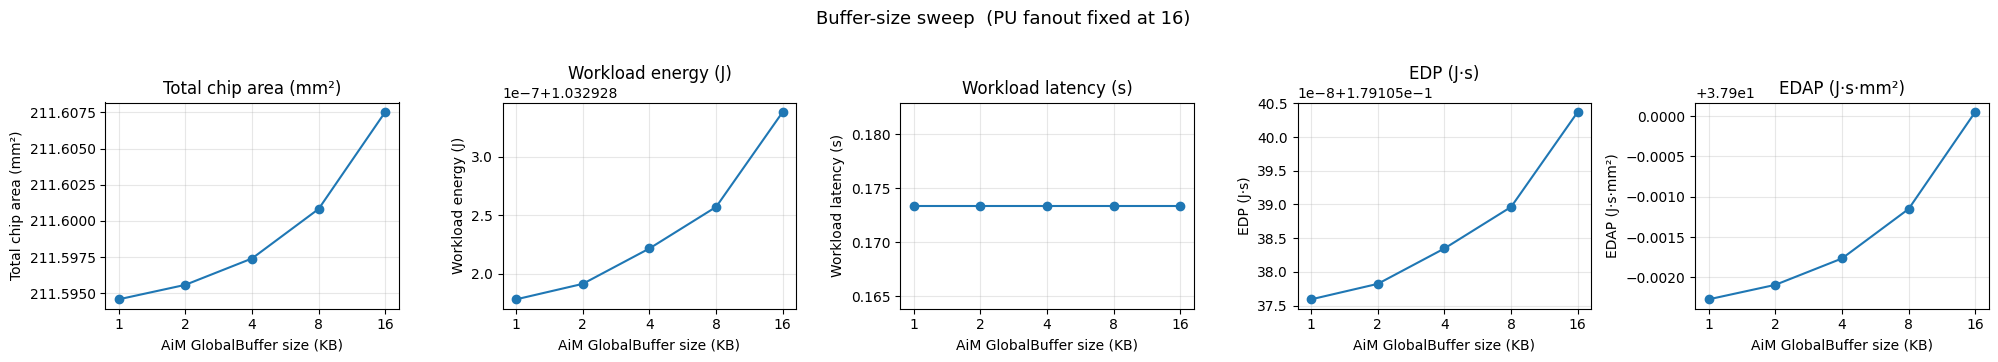

In [16]:
def plot_sweep(sweep_df, x_col, x_label, title_prefix):
    """Line plot of area, energy, latency, EDP, EDAP vs one sweep variable."""
    metrics = [
        ("total_area_mm2", "Total chip area (mm²)"),
        ("energy_j", "Workload energy (J)"),
        ("latency_s", "Workload latency (s)"),
        ("edp", "EDP (J·s)"),
        ("edap", "EDAP (J·s·mm²)"),
    ]
    fig, axes = plt.subplots(1, len(metrics), figsize=(4 * len(metrics), 3.5))
    x = sweep_df[x_col].to_numpy()
    for ax, (col, label) in zip(axes, metrics):
        y = sweep_df[col].to_numpy()
        ax.plot(x, y, marker="o", color="C0")
        ax.set_xlabel(x_label); ax.set_ylabel(label)
        ax.set_title(label)
        ax.grid(True, alpha=0.3)
        # x-axis benefits from log scale for 2×-spaced sweeps
        if np.all(x > 0):
            ratios = (np.diff(np.log2(x)))
            if ratios.size and np.allclose(ratios, ratios[0], atol=0.2):
                ax.set_xscale("log", base=2)
                ax.set_xticks(x)
                ax.set_xticklabels([str(int(v)) for v in x])
    fig.suptitle(title_prefix, fontsize=13, y=1.02)
    plt.tight_layout(); plt.show()


plot_sweep(buf_df, "buffer_kb", "AiM GlobalBuffer size (KB)",
           f"Buffer-size sweep  (PU fanout fixed at {FIXED_FANOUT_FOR_BUFFER_SWEEP})")

## 2. PU-fanout sweep (buffer fixed at 2 KB)

Vary `AIM_PU_FANOUT` over `[8, 12, 16, 24, 32]` (total PUs = fanout²) with the
AiM buffer held at 2 KB. Cached to `fanout_sweep.csv`.

In [ ]:
fan_df, fan_done = load_or_init(FANOUT_CSV, "pu_fanout")
if fan_done:
    print(f"Resuming fanout sweep: {len(fan_done)}/{len(PU_FANOUTS)} cached")

for i, fan in enumerate(PU_FANOUTS, 1):
    if fan in fan_done:
        continue
    t0 = time.time()
    try:
        r = evaluate_config(FIXED_BUF_FOR_FANOUT_SWEEP, fan)
        fan_df = pd.concat([fan_df, pd.DataFrame([r])], ignore_index=True)
        fan_df.to_csv(FANOUT_CSV, index=False)
        print(f"[fan {i}/{len(PU_FANOUTS)}] fanout={fan:>2} ({fan*fan} PUs) -> "
              f"E={r['energy_j']:.3e} J, L={r['latency_s']:.3e} s, "
              f"A={r['total_area_mm2']:.2f} mm²  ({time.time()-t0:.1f}s)")
    except Exception as e:
        print(f"[fan {i}/{len(PU_FANOUTS)}] fanout={fan} FAILED: {e}")

for c in ("buffer_kb", "pu_fanout", "pu_count", "total_area_mm2",
          "aim_buffer_area_mm2", "pu_mac_area_mm2", "energy_j", "latency_s"):
    fan_df[c] = pd.to_numeric(fan_df[c], errors="coerce")
fan_df["edp"] = fan_df["energy_j"] * fan_df["latency_s"]
fan_df["edap"] = fan_df["edp"] * fan_df["total_area_mm2"]
fan_df = fan_df.sort_values("pu_fanout").reset_index(drop=True)
fan_df

[fan 1/5] fanout= 8 (64 PUs) -> E=1.033e+00 J, L=1.819e-01 s, A=209.32 mm²  (22.5s)
[fan 2/5] fanout=12 (144 PUs) -> E=1.033e+00 J, L=1.819e-01 s, A=210.27 mm²  (40.6s)
[fan 3/5] fanout=16 (256 PUs) -> E=1.033e+00 J, L=1.734e-01 s, A=211.60 mm²  (40.8s)
[fan 4/5] fanout=24 (576 PUs) -> E=1.033e+00 J, L=1.734e-01 s, A=215.40 mm²  (31.2s)
[fan 5/5] fanout=32 (1024 PUs) -> E=1.033e+00 J, L=1.733e-01 s, A=220.72 mm²  (27.4s)


,buffer_kb,pu_fanout,pu_count,total_area_mm2,aim_buffer_area_mm2,pu_mac_area_mm2,energy_j,latency_s,edp,edap
0,2,8,64,209.315589,0.001989,0.76,1.032928,0.181915,0.187906,39.331571
1,2,12,144,210.265589,0.001989,1.71,1.032928,0.181915,0.187906,39.510081
2,2,16,256,211.595589,0.001989,3.04,1.032928,0.173396,0.179105,37.897908
3,2,24,576,215.395589,0.001989,6.84,1.032928,0.173396,0.179105,38.578508
4,2,32,1024,220.715589,0.001989,12.16,1.032928,0.173330,0.179038,39.516408


In [4]:
plot_sweep(fan_df, "pu_fanout", "PU fanout (total PUs = fanout²)",
           f"PU-fanout sweep  (buffer fixed at {FIXED_BUF_FOR_FANOUT_SWEEP} KB)")

# AiM-only area contribution as PU fanout scales. The AiM path area is modeled as
# GlobalBuffer area plus total PU_MAC area; TPU-side area is excluded here.
aim_area_df = fan_df.copy()
aim_area_df["aim_total_area_mm2"] = (
    pd.to_numeric(aim_area_df["aim_buffer_area_mm2"], errors="coerce")
    + pd.to_numeric(aim_area_df["pu_mac_area_mm2"], errors="coerce")
)

x = pd.to_numeric(aim_area_df["pu_fanout"], errors="coerce")
fig, ax = plt.subplots(figsize=(6, 4))
ax.stackplot(
    x,
    aim_area_df["aim_buffer_area_mm2"],
    aim_area_df["pu_mac_area_mm2"],
    labels=["AiM GlobalBuffer", "PU MACs"],
    alpha=0.85,
)
ax.plot(x, aim_area_df["aim_total_area_mm2"], marker="o", color="black", label="AiM total")
ax.set_xlabel("PU fanout (side length)")
ax.set_ylabel("AiM area (mm²)")
ax.set_title(f"AiM area vs PU fanout  (buffer fixed at {FIXED_BUF_FOR_FANOUT_SWEEP} KB)")
ax.set_xticks(x)
ax.set_xticklabels([f"{int(v)}\n({int(v*v)} PUs)" for v in x])
ax.grid(True, axis="y", alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

NameError: name 'plot_sweep' is not defined

## 3. Combined results

Concatenate both sweeps into a single DataFrame with a `sweep_axis` label so the
downstream baseline comparison can treat them uniformly.

In [ ]:
buf_tagged = buf_df.assign(sweep_axis="buffer")
fan_tagged = fan_df.assign(sweep_axis="fanout")
df = pd.concat([buf_tagged, fan_tagged], ignore_index=True)
df

## 4. Baseline architectures

To judge whether the swept custom hybrid is actually winning anything, compare
against two reference designs running the **same workload**:

- **TPU-only** (`tpu_only.yaml`) — no AiM path.
- **Base hybrid** (`tpu_aim_hybrid.yaml`) — canonical baseline the sweep customizes.

Each baseline is evaluated once, cached to `baselines.csv`, and reused below.

In [26]:
BASELINES = {
    "tpu_only": EXAMPLES / "arches" / "tpu_only.yaml",
    "base_hybrid": EXAMPLES / "arches" / "tpu_aim_hybrid.yaml",
}
BASELINES_CSV = Path("baselines.csv")


def evaluate_baseline(arch_path: Path) -> dict:
    params = {"BATCH_SIZE": BATCH_SIZE, "N_TOKENS": N_TOKENS}
    # Area
    spec_a = af.Spec.from_yaml(str(arch_path), str(WORKLOAD), jinja_parse_data=params)
    spec_a = spec_a.calculate_component_area_energy_latency_leak()
    area_mm2 = spec_a.arch.total_area * 1e6
    # Energy/latency via mapper
    spec = af.Spec.from_yaml(str(arch_path), str(WORKLOAD), jinja_parse_data=params)
    spec.mapper.metrics = af.Metrics.LATENCY | af.Metrics.ENERGY
    with contextlib.redirect_stdout(io.StringIO()):
        mapping = spec.map_workload_to_arch(print_progress=False)
    energy, latency = pick_edp_best(mapping.energy(), mapping.latency())
    return {
        "total_area_mm2": area_mm2,
        "energy_j": float(energy),
        "latency_s": float(latency),
    }


if BASELINES_CSV.exists():
    baseline_df = pd.read_csv(BASELINES_CSV)
    print(f"Loaded cached baselines ({len(baseline_df)} rows)")
else:
    rows = []
    for name, path in BASELINES.items():
        t0 = time.time()
        print(f"Evaluating baseline {name}...")
        r = evaluate_baseline(path)
        rows.append({"name": name, **r})
        print(f"  -> E={r['energy_j']:.3e} J, L={r['latency_s']:.3e} s, "
              f"A={r['total_area_mm2']:.2f} mm²  ({time.time()-t0:.1f}s)")
    baseline_df = pd.DataFrame(rows)
    baseline_df.to_csv(BASELINES_CSV, index=False)

baseline_df["edp"] = baseline_df["energy_j"] * baseline_df["latency_s"]
baseline_df["edap"] = baseline_df["edp"] * baseline_df["total_area_mm2"]
baseline_df


Evaluating baseline tpu_only...
  -> E=5.431e-01 J, L=3.601e-02 s, A=208.55 mm²  (69.6s)
Evaluating baseline base_hybrid...
  -> E=1.033e+00 J, L=1.734e-01 s, A=211.60 mm²  (48.5s)


,name,total_area_mm2,energy_j,latency_s,edp,edap
0,tpu_only,208.553600,0.543091,0.036014,0.019559,4.079029
1,base_hybrid,211.595589,1.033027,0.173396,0.179123,37.901532


## 5. Improvement of custom hybrid over baselines

For each point in each 1D sweep and each baseline, we compute

> **improvement = baseline_metric / custom_metric**

so **values > 1× mean the custom hybrid is better** than the baseline and
**< 1× means the baseline wins**. Two figures — one per sweep axis — each with
a row of subplots for energy / EDP / EDAP, and one line per baseline.


=== Improvement vs tpu_only (E=5.431e-01 J, L=3.601e-02 s, A=208.55 mm²) ===


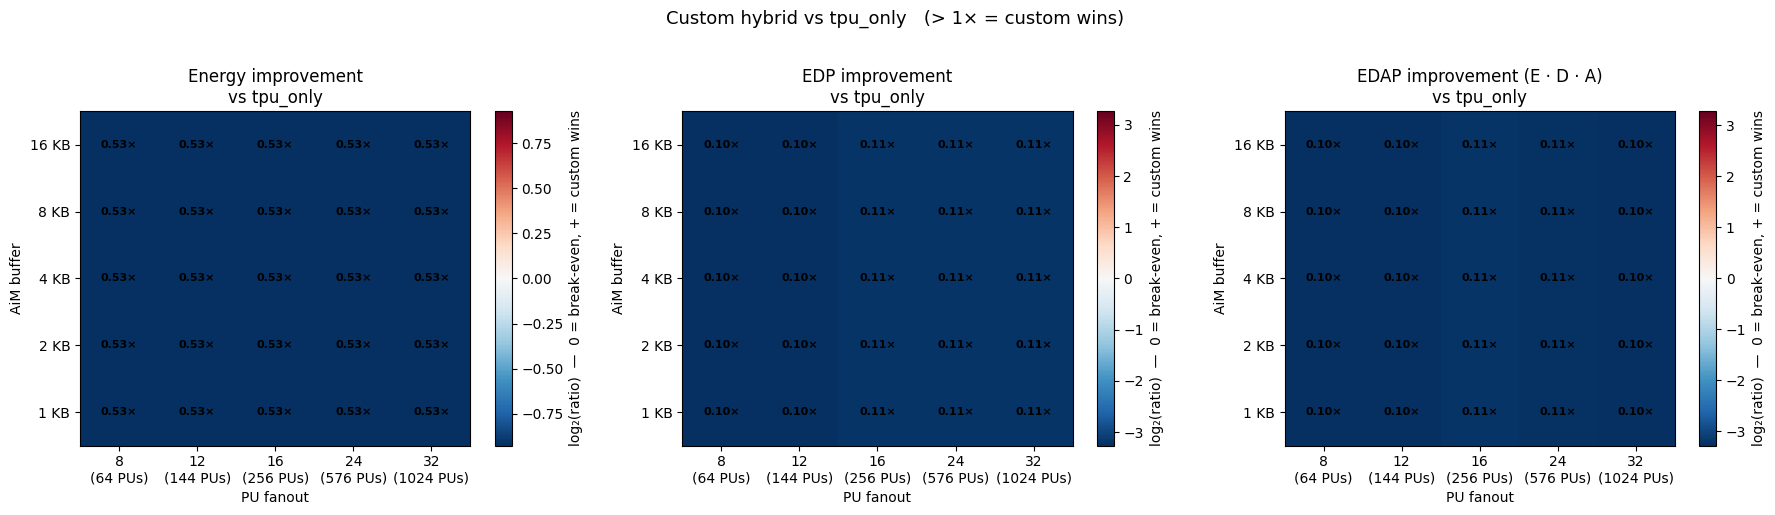

  Best energy vs tpu_only: buf=1KB, fan=32 (1024 PUs) -> 0.526×
  Best EDP   vs tpu_only: buf=1KB, fan=32 (1024 PUs) -> 0.109×
  Best EDAP  vs tpu_only: buf=1KB, fan=16 (256 PUs) -> 0.108×

=== Improvement vs base_hybrid (E=1.033e+00 J, L=1.734e-01 s, A=211.60 mm²) ===


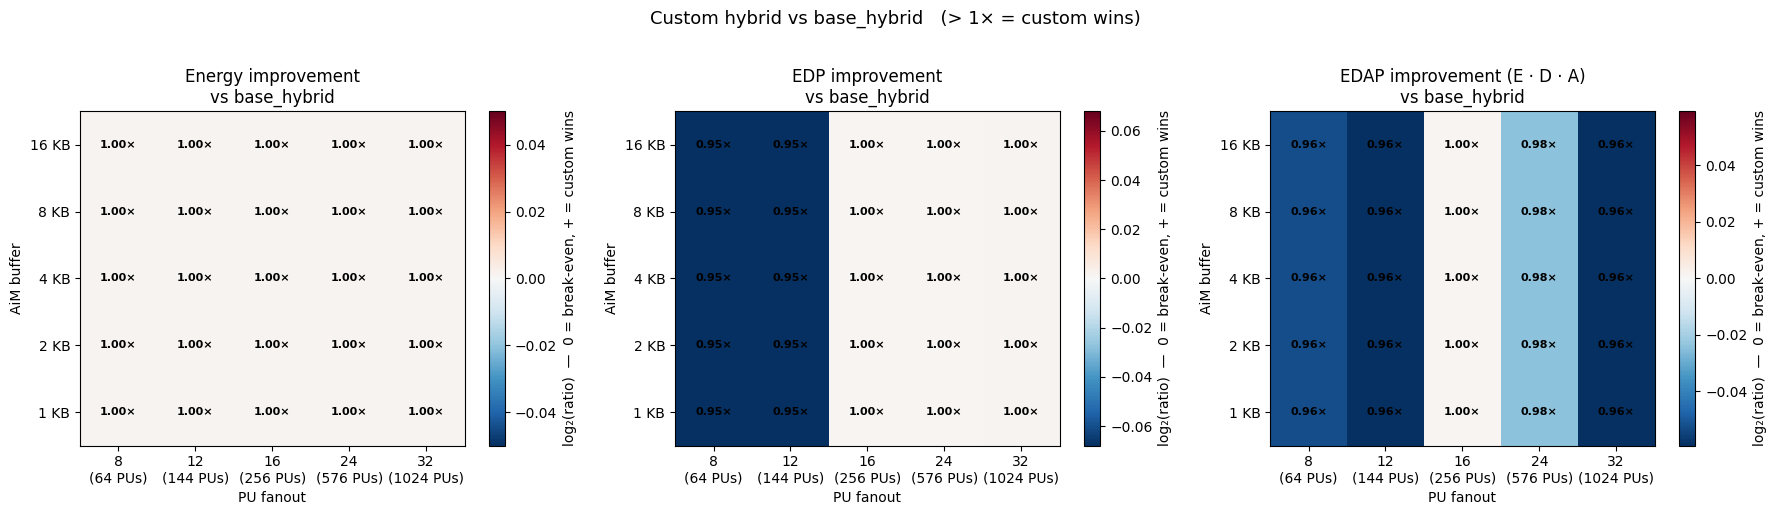

  Best energy vs base_hybrid: buf=1KB, fan=32 (1024 PUs) -> 1.001×
  Best EDP   vs base_hybrid: buf=1KB, fan=32 (1024 PUs) -> 1.001×
  Best EDAP  vs base_hybrid: buf=1KB, fan=16 (256 PUs) -> 1.001×


In [29]:
def improvement_heat(ax, pivot, title, cmap="RdBu_r"):
    data = pivot.to_numpy(dtype=np.float64)
    # Diverging colormap centered at 1.0 (break-even)
    vmax = max(abs(np.log2(np.nanmax(data))), abs(np.log2(np.nanmin(data))))
    vmax = max(vmax, 0.05)
    from matplotlib.colors import TwoSlopeNorm
    norm = TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax)
    im = ax.imshow(np.log2(data), aspect="auto", cmap=cmap, origin="lower", norm=norm)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f"{c}\n({c*c} PUs)" for c in pivot.columns])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f"{r} KB" for r in pivot.index])
    ax.set_xlabel("PU fanout")
    ax.set_ylabel("AiM buffer")
    ax.set_title(title)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.iloc[i, j]
            ax.text(j, i, f"{v:.2f}\u00d7", ha="center", va="center",
                    color="black", fontsize=8, fontweight="bold")
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("log\u2082(ratio)  —  0 = break-even, + = custom wins")


# Build pivoted improvement tables for each baseline
for baseline_name in baseline_df["name"]:
    base = baseline_df[baseline_df["name"] == baseline_name].iloc[0]
    print(f"\n=== Improvement vs {baseline_name} "
          f"(E={base['energy_j']:.3e} J, L={base['latency_s']:.3e} s, "
          f"A={base['total_area_mm2']:.2f} mm\u00b2) ===")

    tmp = df.copy()
    tmp["energy_impr"] = base["energy_j"] / pd.to_numeric(tmp["energy_j"], errors="coerce")
    tmp["edp_impr"] = base["edp"] / pd.to_numeric(tmp["edp"], errors="coerce")
    tmp["edap_impr"] = base["edap"] / pd.to_numeric(tmp["edap"], errors="coerce")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, metric, label in [
        (axes[0], "energy_impr", "Energy improvement"),
        (axes[1], "edp_impr", "EDP improvement"),
        (axes[2], "edap_impr", "EDAP improvement (E \u00b7 D \u00b7 A)"),
    ]:
        pivot = (tmp.pivot_table(index="buffer_kb", columns="pu_fanout",
                                 values=metric, aggfunc="first")
                 .sort_index().sort_index(axis=1))
        improvement_heat(ax, pivot, f"{label}\nvs {baseline_name}")
    fig.suptitle(f"Custom hybrid vs {baseline_name}   (> 1\u00d7 = custom wins)",
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

    # Summary: best custom config per metric against this baseline
    for metric, label in [("energy_impr", "energy"),
                          ("edp_impr", "EDP"),
                          ("edap_impr", "EDAP")]:
        best_row = tmp.loc[pd.to_numeric(tmp[metric], errors="coerce").idxmax()]
        print(f"  Best {label:5s} vs {baseline_name}: "
              f"buf={int(best_row.buffer_kb)}KB, fan={int(best_row.pu_fanout)} "
              f"({int(best_row.pu_count)} PUs) -> {best_row[metric]:.3f}\u00d7")


## 8. Best configurations

Top 5 by each metric.

In [28]:
cols = ["buffer_kb", "pu_fanout", "pu_count",
        "total_area_mm2", "energy_j", "latency_s", "edp", "edap"]
num = ["energy_j", "latency_s", "edp", "edap", "total_area_mm2"]
_rank = df.copy()
for c in num:
    _rank[c] = pd.to_numeric(_rank[c], errors="coerce")

for metric in num:
    print(f"\n== Top 5 by {metric} (lowest) ==")
    valid = _rank.dropna(subset=[metric])
    print(valid.nsmallest(5, metric)[cols].to_string(index=False))


== Top 5 by energy_j (lowest) ==
 buffer_kb  pu_fanout  pu_count  total_area_mm2  energy_j  latency_s      edp      edap
         1         32      1024      220.714588  1.032112   0.173330 0.178896 39.485009
         1         16       256      211.594588  1.032112   0.173396 0.178964 37.867788
         1         24       576      215.394588  1.032112   0.173396 0.178964 38.547851
         1          8        64      209.314588  1.032112   0.181915 0.187757 39.300309
         1         12       144      210.264588  1.032112   0.181915 0.187757 39.478678

== Top 5 by latency_s (lowest) ==
 buffer_kb  pu_fanout  pu_count  total_area_mm2  energy_j  latency_s      edp      edap
         1         32      1024      220.714588  1.032112    0.17333 0.178896 39.485009
         2         32      1024      220.715589  1.032112    0.17333 0.178896 39.485189
         4         32      1024      220.717409  1.032112    0.17333 0.178896 39.485516
         8         32      1024      220.720830  1.

## 9. Bandwidth sweep: MainMemory (internal) vs OffChipLink (external)

Independent experiment: hold AiM (buffer=2 KB, fanout=16) and sweep the memory
bandwidths driving the mapper's latencies:

- `HBM_INTERNAL_GBPS` — DRAM internal bandwidth, sets `MainMemory` read/write latency.
- `HBM_EXTERNAL_GBPS` — DRAM external / off-chip bandwidth, sets `OffChipLink` read latency.

Reports **EDP improvement relative to the default (512 GB/s internal, 32 GB/s external)**
point, so values > 1× mean faster memory at that design point yields better EDP.
Cached to `bandwidth_sweep.csv`.

In [34]:
BW_CSV = Path("bandwidth_sweep.csv")

DEFAULT_INTERNAL_GBPS = 512
DEFAULT_EXTERNAL_GBPS = 32
INTERNAL_GBPS = [64, 128, 256, 512, 1024]    # MainMemory internal
EXTERNAL_GBPS = [32, 64, 128, 256, 512]           # OffChipLink external

FIXED_BUF_KB = 2
FIXED_FANOUT = 16
N_TOKENS = 8192
# Per-MAC action energies from the arch yaml — used to reverse-engineer MAC counts.
TPU_MAC_E_PER_OP = 0.084e-12    # see TPU_MAC action in tpu_aim_hybrid_sweep.yaml
AIM_MAC_E_PER_OP = 0.48e-12      # see PU_MAC action in tpu_aim_hybrid_sweep.yaml

EXPECTED_COLS = [
    "internal_gbps", "external_gbps", "energy_j", "latency_s",
    "tpu_mac_e_j", "aim_mac_e_j", "mainmem_latency_s", "offchip_latency_s",
]


def evaluate_bandwidth(internal_gbps: int, external_gbps: int) -> dict:
    params = {
        "BATCH_SIZE": BATCH_SIZE,
        "N_TOKENS": N_TOKENS,
        "AIM_BUFFER_KB": FIXED_BUF_KB,
        "AIM_PU_FANOUT": FIXED_FANOUT,
        "HBM_INTERNAL_GBPS": internal_gbps,
        "HBM_EXTERNAL_GBPS": external_gbps,
    }
    spec = af.Spec.from_yaml(str(ARCH), str(WORKLOAD), jinja_parse_data=params)
    spec.mapper.metrics = af.Metrics.LATENCY | af.Metrics.ENERGY
    with contextlib.redirect_stdout(io.StringIO()):
        mapping = spec.map_workload_to_arch(
            einsum_names=["Q_new"],
            print_progress=False,
        )

    energies = mapping.energy()
    latencies = mapping.latency()
    if isinstance(energies, list):
        idx = min(range(len(energies)), key=lambda i: energies[i] * latencies[i])
        chosen = mapping[idx]
        e_total, l_total = float(energies[idx]), float(latencies[idx])
    else:
        chosen = mapping
        e_total, l_total = float(energies), float(latencies)

    per_comp_e = chosen.energy(per_component=True)
    per_comp_l = chosen.latency(per_component=True)

    return {
        "energy_j": e_total,
        "latency_s": l_total,
        "tpu_mac_e_j": float(per_comp_e.get("TPU_MAC", 0.0)),
        "aim_mac_e_j": float(per_comp_e.get("PU_MAC", 0.0)),
        "mainmem_latency_s": float(per_comp_l.get("MainMemory", 0.0)),
        "offchip_latency_s": float(per_comp_l.get("OffChipLink", 0.0)),
    }


# Load or initialize cache. If existing CSV is missing new columns (old schema),
# discard it and re-run so the per-path fields are populated.
if BW_CSV.exists():
    bw_df = pd.read_csv(BW_CSV)
    missing = [c for c in EXPECTED_COLS if c not in bw_df.columns]
    if missing:
        print(f"Cache missing columns {missing}; discarding and re-running.")
        bw_df = pd.DataFrame(columns=EXPECTED_COLS)
        done_bw = set()
    else:
        done_bw = {(int(r.internal_gbps), int(r.external_gbps))
                   for r in bw_df.itertuples()}
        print(f"Resuming: {len(done_bw)}/{len(INTERNAL_GBPS)*len(EXTERNAL_GBPS)} cached")
else:
    bw_df = pd.DataFrame(columns=EXPECTED_COLS)
    done_bw = set()

grid = [(i, e) for i in INTERNAL_GBPS for e in EXTERNAL_GBPS]
for k, (ig, eg) in enumerate(grid, 1):
    if (ig, eg) in done_bw:
        continue
    t0 = time.time()
    try:
        r = evaluate_bandwidth(ig, eg)
        row = {"internal_gbps": ig, "external_gbps": eg, **r}
        bw_df = pd.concat([bw_df, pd.DataFrame([row])], ignore_index=True)
        bw_df.to_csv(BW_CSV, index=False)
        # Quick path hint in the progress line
        mac_frac = (r["tpu_mac_e_j"] / TPU_MAC_E_PER_OP) / max(
            r["tpu_mac_e_j"] / TPU_MAC_E_PER_OP + r["aim_mac_e_j"] / AIM_MAC_E_PER_OP,
            1e-30,
        )
        print(f"[{k:2d}/{len(grid)}] int={ig:>4} ext={eg:>3} GB/s -> "
              f"E={r['energy_j']:.3e} J, L={r['latency_s']:.3e} s, "
              f"TPU-MAC frac={mac_frac:.2f}  ({time.time()-t0:.1f}s)")
    except Exception as e:
        print(f"[{k:2d}/{len(grid)}] int={ig} ext={eg} FAILED: {e}")

# Derived columns used by the plots below
for c in ("energy_j", "latency_s", "tpu_mac_e_j", "aim_mac_e_j",
          "mainmem_latency_s", "offchip_latency_s"):
    bw_df[c] = pd.to_numeric(bw_df[c], errors="coerce")
bw_df["edp"] = bw_df["energy_j"] * bw_df["latency_s"]
bw_df["tpu_macs_est"] = bw_df["tpu_mac_e_j"] / TPU_MAC_E_PER_OP
bw_df["aim_macs_est"] = bw_df["aim_mac_e_j"] / AIM_MAC_E_PER_OP
bw_df["total_macs_est"] = bw_df["tpu_macs_est"] + bw_df["aim_macs_est"]
bw_df["mac_frac_tpu"] = bw_df["tpu_macs_est"] / bw_df["total_macs_est"].where(
    bw_df["total_macs_est"] > 0)
bw_df["achieved_tops"] = 2 * bw_df["total_macs_est"] / bw_df["latency_s"] / 1e12
# Arithmetic intensity vs HBM: bytes = MainMemory_latency × internal_bandwidth.
bw_df["hbm_bytes_est"] = bw_df["mainmem_latency_s"] * bw_df["internal_gbps"] * 1e9
bw_df["arith_intensity"] = (
    2 * bw_df["total_macs_est"] / bw_df["hbm_bytes_est"].where(bw_df["hbm_bytes_est"] > 0))

bw_df.sort_values(["internal_gbps", "external_gbps"])

python(18337) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(18338) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(18339) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(18340) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(18341) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(18342) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(18343) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(18344) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


[ 1/25] int=  64 ext= 32 GB/s -> E=6.940e-03 J, L=2.507e-03 s, TPU-MAC frac=0.00  (9.6s)
[ 2/25] int=  64 ext= 64 GB/s -> E=6.940e-03 J, L=2.507e-03 s, TPU-MAC frac=0.00  (6.1s)
[ 3/25] int=  64 ext=128 GB/s -> E=6.940e-03 J, L=2.507e-03 s, TPU-MAC frac=0.00  (4.1s)
[ 4/25] int=  64 ext=256 GB/s -> E=6.940e-03 J, L=2.507e-03 s, TPU-MAC frac=0.00  (4.5s)
[ 5/25] int=  64 ext=512 GB/s -> E=6.940e-03 J, L=2.507e-03 s, TPU-MAC frac=0.00  (3.5s)
[ 6/25] int= 128 ext= 32 GB/s -> E=7.269e-03 J, L=1.327e-03 s, TPU-MAC frac=0.00  (3.7s)
[ 7/25] int= 128 ext= 64 GB/s -> E=7.269e-03 J, L=1.327e-03 s, TPU-MAC frac=0.00  (3.9s)
[ 8/25] int= 128 ext=128 GB/s -> E=7.269e-03 J, L=1.327e-03 s, TPU-MAC frac=0.00  (7.6s)
[ 9/25] int= 128 ext=256 GB/s -> E=7.269e-03 J, L=1.327e-03 s, TPU-MAC frac=0.00  (4.7s)
[10/25] int= 128 ext=512 GB/s -> E=7.269e-03 J, L=1.327e-03 s, TPU-MAC frac=0.00  (4.1s)
[11/25] int= 256 ext= 32 GB/s -> E=7.672e-03 J, L=7.004e-04 s, TPU-MAC frac=0.00  (4.6s)
[12/25] int= 256 ext=

,internal_gbps,external_gbps,energy_j,latency_s,tpu_mac_e_j,aim_mac_e_j,mainmem_latency_s,offchip_latency_s,edp,tpu_macs_est,aim_macs_est,total_macs_est,mac_frac_tpu,achieved_tops,hbm_bytes_est,arith_intensity
0,64,32,0.006940,0.002507,0.0,0.000072,0.002507,0.0,0.000017,0.0,150994944.0,150994944.0,0.0,0.120461,160444408.655167,1.882209
1,64,64,0.006940,0.002507,0.0,0.000072,0.002507,0.0,0.000017,0.0,150994944.0,150994944.0,0.0,0.120461,160444408.655167,1.882209
2,64,128,0.006940,0.002507,0.0,0.000072,0.002507,0.0,0.000017,0.0,150994944.0,150994944.0,0.0,0.120461,160444408.655167,1.882209
3,64,256,0.006940,0.002507,0.0,0.000072,0.002507,0.0,0.000017,0.0,150994944.0,150994944.0,0.0,0.120461,160444408.655167,1.882209
4,64,512,0.006940,0.002507,0.0,0.000072,0.002507,0.0,0.000017,0.0,150994944.0,150994944.0,0.0,0.120461,160444408.655167,1.882209
5,128,32,0.007269,0.001327,0.0,0.000072,0.001327,0.0,0.000010,0.0,150994944.0,150994944.0,0.0,0.227556,169869318.604469,1.777778
6,128,64,0.007269,0.001327,0.0,0.000072,0.001327,0.0,0.000010,0.0,150994944.0,150994944.0,0.0,0.227556,169869318.604469,1.777778
7,128,128,0.007269,0.001327,0.0,0.000072,0.001327,0.0,0.000010,0.0,150994944.0,150994944.0,0.0,0.227556,169869318.604469,1.777778
8,128,256,0.007269,0.001327,0.0,0.000072,0.001327,0.0,0.000010,0.0,150994944.0,150994944.0,0.0,0.227556,169869318.604469,1.777778
9,128,512,0.007269,0.001327,0.0,0.000072,0.001327,0.0,0.000010,0.0,150994944.0,150994944.0,0.0,0.227556,169869318.604469,1.777778


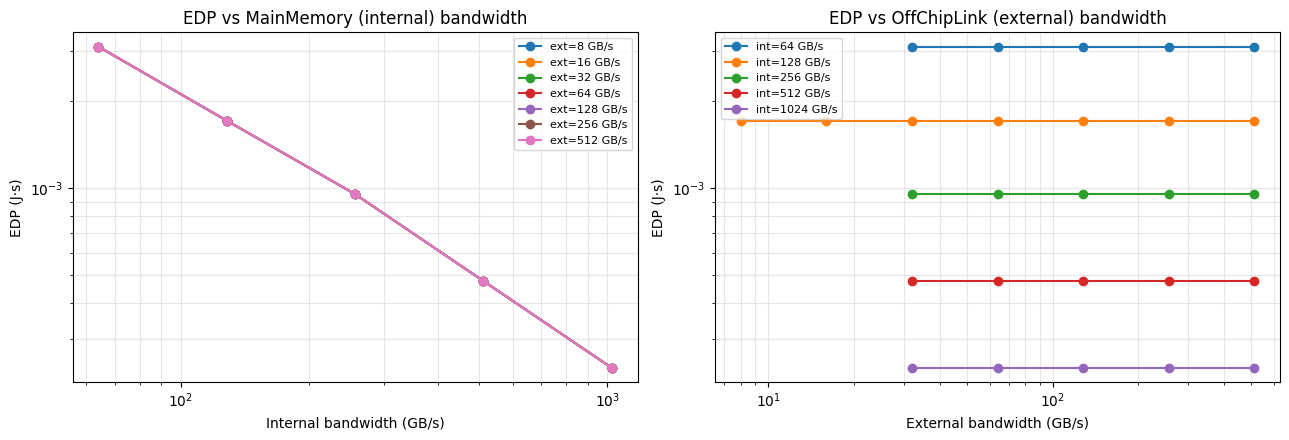

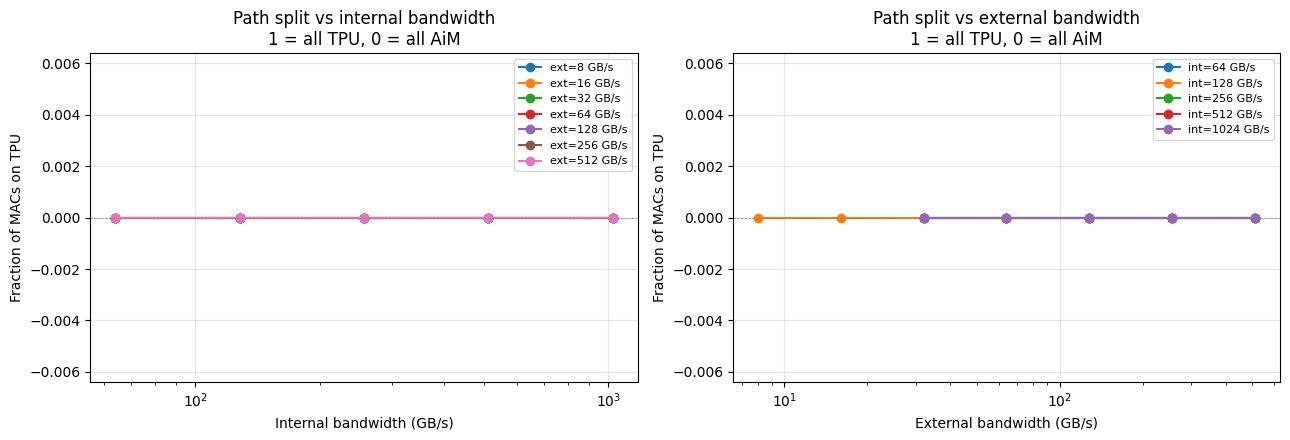

/var/folders/6w/67zfghgn3s7_mv67l9xttj680000gn/T/ipykernel_64806/3806855812.py:101: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axR.set_xscale("log"); axR.set_yscale("log")


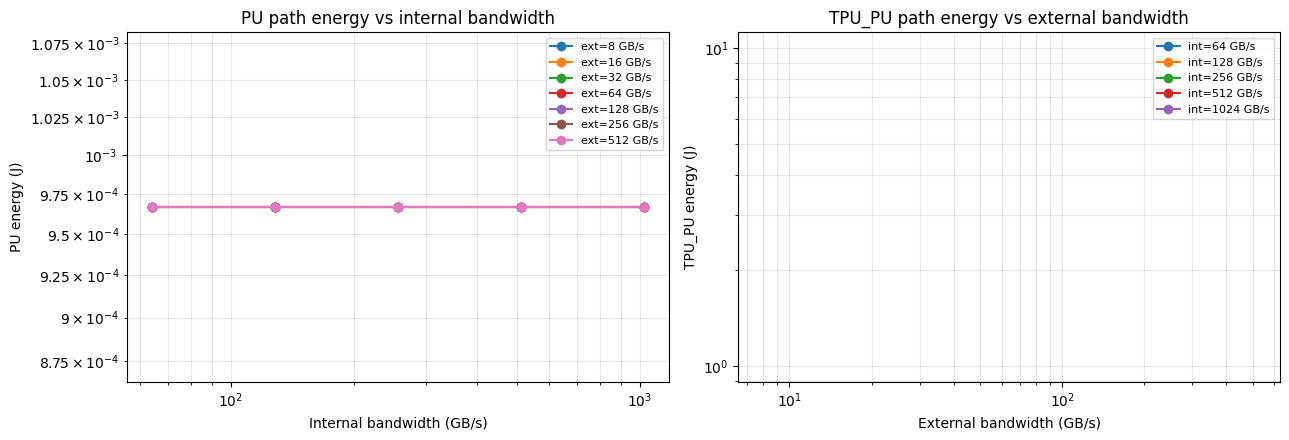

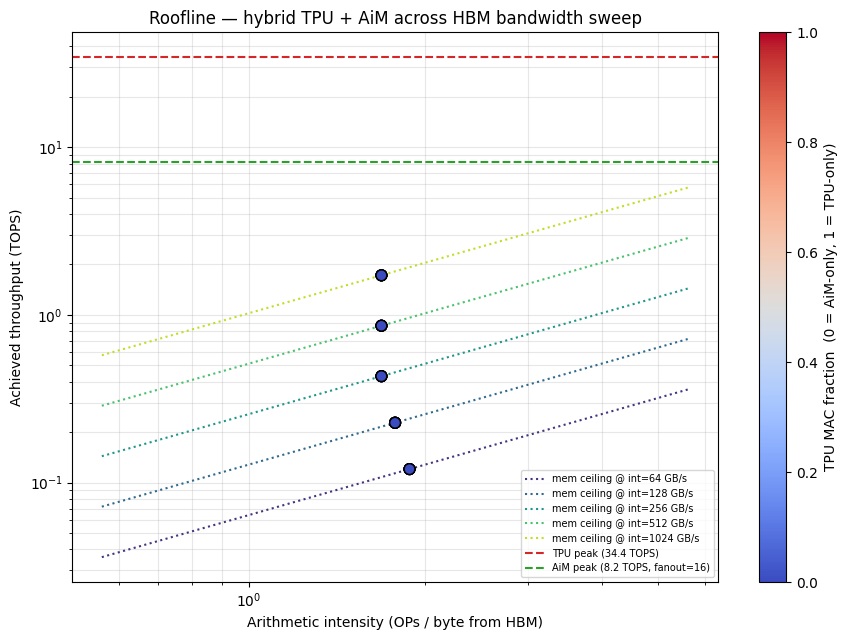

In [32]:
# ---------- Peak throughputs (OPs/s) derived from the arch yaml ----------
# TPU_MAC:  1/1.05e9 s/MAC, fanout 128 × 128 = 16384 MACs
# PU_MAC:   1/(FREQ_GHZ*16)e9 s/MAC at FREQ_GHZ=1 -> 16 GMAC/s per PU,
#           AIM_PU_FANOUT × AIM_PU_FANOUT PUs total.
TPU_PEAK_TOPS = 128 * 128 * 1.05e9 * 2 / 1e12
AIM_PEAK_TOPS = FIXED_FANOUT * FIXED_FANOUT * 16e9 * 2 / 1e12

int_vals = sorted(bw_df["internal_gbps"].unique())
ext_vals = sorted(bw_df["external_gbps"].unique())


def set_auto_ylim(ax, values, log=False, pad_frac=0.12):
    vals = np.asarray(values, dtype=np.float64)
    vals = vals[np.isfinite(vals)]
    if log:
        vals = vals[vals > 0]
    if vals.size == 0:
        return
    vmin, vmax = float(vals.min()), float(vals.max())
    if log:
        if vmax <= vmin:
            vmin *= 0.8
            vmax *= 1.2
        else:
            vmin /= (1 + pad_frac)
            vmax *= (1 + pad_frac)
        ax.set_ylim(max(vmin, np.finfo(float).tiny), vmax)
    else:
        span = vmax - vmin
        if span == 0:
            span = max(abs(vmax), 1.0) * pad_frac
        pad = span * pad_frac
        ax.set_ylim(vmin - pad, vmax + pad)

# ---------------------- Figure 1: EDP line plots ----------------------
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.5))
for eg in ext_vals:
    sub = bw_df[bw_df["external_gbps"] == eg].sort_values("internal_gbps")
    axL.plot(sub["internal_gbps"], sub["edp"], marker="o", label=f"ext={eg} GB/s")
axL.set_xscale("log"); axL.set_yscale("log")
set_auto_ylim(axL, bw_df["edp"], log=True)
axL.set_xlabel("Internal bandwidth (GB/s)"); axL.set_ylabel("EDP (J·s)")
axL.set_title("EDP vs MainMemory (internal) bandwidth")
axL.grid(True, which="both", alpha=0.3); axL.legend(fontsize=8)

for ig in int_vals:
    sub = bw_df[bw_df["internal_gbps"] == ig].sort_values("external_gbps")
    axR.plot(sub["external_gbps"], sub["edp"], marker="o", label=f"int={ig} GB/s")
axR.set_xscale("log"); axR.set_yscale("log")
set_auto_ylim(axR, bw_df["edp"], log=True)
axR.set_xlabel("External bandwidth (GB/s)"); axR.set_ylabel("EDP (J·s)")
axR.set_title("EDP vs OffChipLink (external) bandwidth")
axR.grid(True, which="both", alpha=0.3); axR.legend(fontsize=8)
plt.tight_layout(); plt.show()


# ---------------------- Figure 2: compute-path utilization ----------------------
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.5))
for eg in ext_vals:
    sub = bw_df[bw_df["external_gbps"] == eg].sort_values("internal_gbps")
    axL.plot(sub["internal_gbps"], sub["mac_frac_tpu"], marker="o", label=f"ext={eg} GB/s")
axL.axhline(1.0, color="gray", ls="--", lw=0.5)
axL.axhline(0.0, color="gray", ls="--", lw=0.5)
axL.set_xscale("log")
set_auto_ylim(axL, bw_df["mac_frac_tpu"], log=False, pad_frac=0.08)
axL.set_xlabel("Internal bandwidth (GB/s)"); axL.set_ylabel("Fraction of MACs on TPU")
axL.set_title("Path split vs internal bandwidth\n1 = all TPU, 0 = all AiM")
axL.grid(True, alpha=0.3); axL.legend(fontsize=8)

for ig in int_vals:
    sub = bw_df[bw_df["internal_gbps"] == ig].sort_values("external_gbps")
    axR.plot(sub["external_gbps"], sub["mac_frac_tpu"], marker="o", label=f"int={ig} GB/s")
axR.axhline(1.0, color="gray", ls="--", lw=0.5)
axR.axhline(0.0, color="gray", ls="--", lw=0.5)
axR.set_xscale("log")
set_auto_ylim(axR, bw_df["mac_frac_tpu"], log=False, pad_frac=0.08)
axR.set_xlabel("External bandwidth (GB/s)"); axR.set_ylabel("Fraction of MACs on TPU")
axR.set_title("Path split vs external bandwidth\n1 = all TPU, 0 = all AiM")
axR.grid(True, alpha=0.3); axR.legend(fontsize=8)
plt.tight_layout(); plt.show()


# ---------------------- Figure 2b: per-path energy vs bandwidth ----------------------
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.5))

# PU path energy as internal bandwidth increases (one line per external BW)
for eg in ext_vals:
    sub = bw_df[bw_df["external_gbps"] == eg].sort_values("internal_gbps")
    axL.plot(sub["internal_gbps"], sub["aim_mac_e_j"], marker="o", label=f"ext={eg} GB/s")
axL.set_xscale("log"); axL.set_yscale("log")
set_auto_ylim(axL, bw_df["aim_mac_e_j"], log=True)
axL.set_xlabel("Internal bandwidth (GB/s)")
axL.set_ylabel("PU energy (J)")
axL.set_title("PU path energy vs internal bandwidth")
axL.grid(True, which="both", alpha=0.3); axL.legend(fontsize=8)

# TPU path energy as external bandwidth increases (one line per internal BW)
for ig in int_vals:
    sub = bw_df[bw_df["internal_gbps"] == ig].sort_values("external_gbps")
    axR.plot(sub["external_gbps"], sub["tpu_mac_e_j"], marker="o", label=f"int={ig} GB/s")
axR.set_xscale("log"); axR.set_yscale("log")
set_auto_ylim(axR, bw_df["tpu_mac_e_j"], log=True)
axR.set_xlabel("External bandwidth (GB/s)")
axR.set_ylabel("TPU_PU energy (J)")
axR.set_title("TPU_PU path energy vs external bandwidth")
axR.grid(True, which="both", alpha=0.3); axR.legend(fontsize=8)

plt.tight_layout(); plt.show()


# ---------------------- Figure 3: Roofline ----------------------
fig, ax = plt.subplots(figsize=(9, 6.5))

# Arithmetic-intensity axis covers the observed range with padding
ai_valid = bw_df["arith_intensity"].dropna()
ai_valid = ai_valid[ai_valid > 0]
if len(ai_valid):
    ai_min, ai_max = ai_valid.min() / 3, ai_valid.max() * 3
else:
    ai_min, ai_max = 1e-2, 1e3
ai_range = np.logspace(np.log10(ai_min), np.log10(ai_max), 200)

# Sloped memory ceilings, one per internal bandwidth
cmap = plt.cm.viridis(np.linspace(0.15, 0.9, len(int_vals)))
for ig, color in zip(int_vals, cmap):
    y = ai_range * ig * 1e9 / 1e12  # TOPS: bytes/s × OP/byte = OPs/s
    ax.plot(ai_range, y, color=color, ls=":", lw=1.5,
            label=f"mem ceiling @ int={ig} GB/s")

# Horizontal compute ceilings
ax.axhline(TPU_PEAK_TOPS, color="C3", ls="--", lw=1.5,
           label=f"TPU peak ({TPU_PEAK_TOPS:.1f} TOPS)")
ax.axhline(AIM_PEAK_TOPS, color="C2", ls="--", lw=1.5,
           label=f"AiM peak ({AIM_PEAK_TOPS:.1f} TOPS, fanout={FIXED_FANOUT})")

# Achieved points, colored by which path was chosen
pts = bw_df.dropna(subset=["arith_intensity", "achieved_tops"])
sc = ax.scatter(pts["arith_intensity"], pts["achieved_tops"],
                c=pts["mac_frac_tpu"], cmap="coolwarm", vmin=0, vmax=1,
                s=60, edgecolor="black", zorder=10)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("TPU MAC fraction  (0 = AiM-only, 1 = TPU-only)")

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Arithmetic intensity (OPs / byte from HBM)")
ax.set_ylabel("Achieved throughput (TOPS)")
ax.set_title("Roofline — hybrid TPU + AiM across HBM bandwidth sweep")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=7, loc="lower right")
plt.tight_layout(); plt.show()

EDAP-optimal Q_new decode PU-fanout point:
  fanout=16 (256 PUs), area=3.040e-06 mm², E=7.672e-03 J, L=3.502e-04 s, EDAP=8.168e-12 J*s*mm²
EDAP-optimal Q_new prefill HBM-external point:
  external=32 GB/s, area=3.040e-06 mm², E=2.283e-01 J, L=1.798e-02 s, EDAP=1.248e-08 J*s*mm²


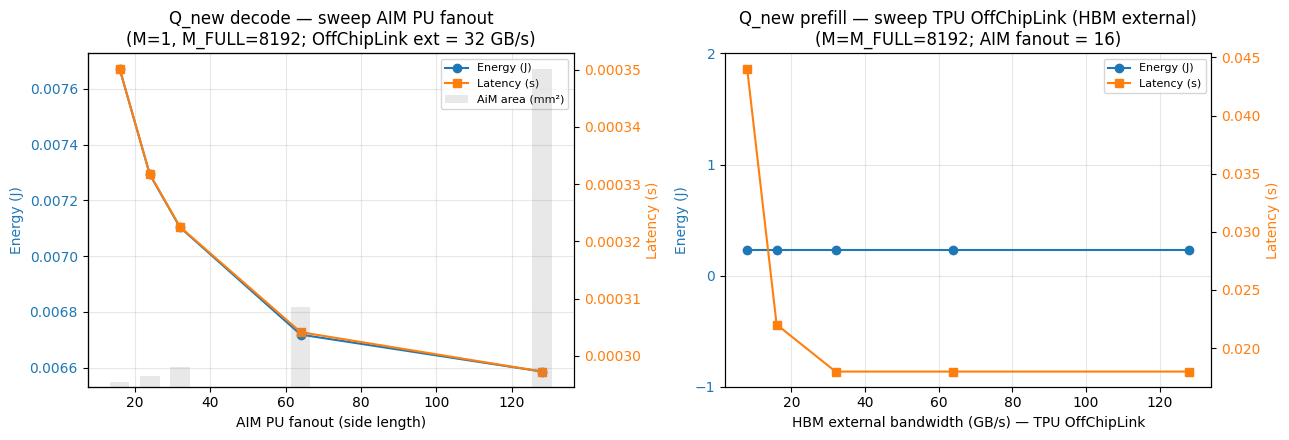

In [8]:
# Q_new on hybrid: sweep AIM PU fanout under decode, and sweep TPU OffChipLink
# (HBM external) under prefill.
# Decode: N_NEW_TOKENS=1, N_TOKENS = KV length (one step vs full cache).
# Prefill: N_NEW_TOKENS = N_TOKENS (full prompt in one shot).
# Requires earlier cell with BATCH_SIZE, N_TOKENS (full context / prompt length).

import contextlib
import io
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import accelforge as af

_ex = Path("../examples")
HYBRID_SWEEP_ARCH = _ex / "arches" / "tpu_aim_hybrid_sweep.yaml"
_Q_WL = _ex / "workloads" / "gpt3_6.7B_kv_cache.yaml"

_Q_PARAMS_BASE = {
    "AIM_BUFFER_KB": 2,
    "HBM_INTERNAL_GBPS": 512,
}
PU_FANOUT_SWEEP = [16, 24, 32, 64, 128]
HBM_EXTERNAL_SWEEP = [8, 16, 32, 64, 128]
_FIXED_EXT_FOR_FANOUT_SWEEP = 32
_FIXED_FANOUT_FOR_EXT_SWEEP = 16

# Same sequence length for both phases (typical: prompt length = cache length).
_CTX = int(N_TOKENS)


def _pick_edp(mapping):
    energies = mapping.energy()
    latencies = mapping.latency()
    if isinstance(energies, list):
        idx = min(range(len(energies)), key=lambda i: energies[i] * latencies[i])
        e, l = float(energies[idx]), float(latencies[idx])
    else:
        e, l = float(energies), float(latencies)
    return e, l, e * l


def _q_new_params(
    aim_fanout: int,
    hbm_external: int,
    *,
    n_tokens: int,
    n_new_tokens: int,
) -> dict:
    return {
        "BATCH_SIZE": BATCH_SIZE,
        "N_TOKENS": n_tokens,
        "N_NEW_TOKENS": n_new_tokens,
        **_Q_PARAMS_BASE,
        "AIM_PU_FANOUT": aim_fanout,
        "HBM_EXTERNAL_GBPS": hbm_external,
    }


def _aim_area_mm2(params: dict) -> float:
    spec = af.Spec.from_yaml(str(HYBRID_SWEEP_ARCH), str(_Q_WL), jinja_parse_data=params)
    spec = spec.calculate_component_area_energy_latency_leak()
    per_comp = dict(spec.arch.per_component_total_area)
    return  per_comp.get("PU_MAC", 0.0)


def _map_q_new(
    aim_fanout: int,
    hbm_external: int,
    *,
    n_tokens: int,
    n_new_tokens: int,
) -> tuple[float, float, float]:
    params = _q_new_params(
        aim_fanout,
        hbm_external,
        n_tokens=n_tokens,
        n_new_tokens=n_new_tokens,
    )
    spec = af.Spec.from_yaml(
        str(HYBRID_SWEEP_ARCH), str(_Q_WL), jinja_parse_data=params
    )
    spec.mapper.metrics = af.Metrics.LATENCY | af.Metrics.ENERGY
    with contextlib.redirect_stdout(io.StringIO()):
        m = spec.map_workload_to_arch(einsum_names=["Q_new"], print_progress=False)
    return _pick_edp(m)


# Decode: one new token, full KV length M_FULL = _CTX
rows_fanout = []
for f in PU_FANOUT_SWEEP:
    params = _q_new_params(
        f,
        _FIXED_EXT_FOR_FANOUT_SWEEP,
        n_tokens=_CTX,
        n_new_tokens=1,
    )
    e, l, edp = _map_q_new(
        f,
        _FIXED_EXT_FOR_FANOUT_SWEEP,
        n_tokens=_CTX,
        n_new_tokens=1,
    )
    rows_fanout.append({
        "aim_fanout": f,
        "aim_area_mm2": _aim_area_mm2(params),
        "energy_j": e,
        "latency_s": l,
        "edp_j_s": edp,
    })

# Prefill: all prompt tokens at once (M = M_FULL = _CTX)
rows_ext = []
for g in HBM_EXTERNAL_SWEEP:
    params = _q_new_params(
        _FIXED_FANOUT_FOR_EXT_SWEEP,
        g,
        n_tokens=_CTX,
        n_new_tokens=_CTX,
    )
    e, l, edp = _map_q_new(
        _FIXED_FANOUT_FOR_EXT_SWEEP,
        g,
        n_tokens=_CTX,
        n_new_tokens=_CTX,
    )
    rows_ext.append({
        "hbm_external_gbps": g,
        "aim_area_mm2": _aim_area_mm2(params),
        "energy_j": e,
        "latency_s": l,
        "edp_j_s": edp,
    })

df_fan = pd.DataFrame(rows_fanout)
df_ext = pd.DataFrame(rows_ext)
df_fan["edap_j_s_mm2"] = df_fan["edp_j_s"] * df_fan["aim_area_mm2"]
df_ext["edap_j_s_mm2"] = df_ext["edp_j_s"] * df_ext["aim_area_mm2"]

best_fan = df_fan.loc[df_fan["edap_j_s_mm2"].idxmin()]
best_ext = df_ext.loc[df_ext["edap_j_s_mm2"].idxmin()]
print("EDAP-optimal Q_new decode PU-fanout point:")
print(
    f"  fanout={int(best_fan.aim_fanout)} ({int(best_fan.aim_fanout**2)} PUs), "
    f"area={best_fan.aim_area_mm2:.3e} mm², "
    f"E={best_fan.energy_j:.3e} J, L={best_fan.latency_s:.3e} s, "
    f"EDAP={best_fan.edap_j_s_mm2:.3e} J*s*mm²"
)
print("EDAP-optimal Q_new prefill HBM-external point:")
print(
    f"  external={int(best_ext.hbm_external_gbps)} GB/s, "
    f"area={best_ext.aim_area_mm2:.3e} mm², "
    f"E={best_ext.energy_j:.3e} J, L={best_ext.latency_s:.3e} s, "
    f"EDAP={best_ext.edap_j_s_mm2:.3e} J*s*mm²"
)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.5))

(l_e,) = axL.plot(df_fan["aim_fanout"], df_fan["energy_j"], marker="o", color="C0", label="Energy (J)")
axL.set_xlabel("AIM PU fanout (side length)")
axL.set_ylabel("Energy (J)", color="C0")
axL.tick_params(axis="y", labelcolor="C0")
axL_t = axL.twinx()
(l_l,) = axL_t.plot(df_fan["aim_fanout"], df_fan["latency_s"], marker="s", color="C1", label="Latency (s)")
axL_t.set_ylabel("Latency (s)", color="C1")
axL_t.tick_params(axis="y", labelcolor="C1")

# Overlay AiM area as histogram-style bars on the same fanout x-axis.
axL_area = axL.twinx()
axL_area.spines["right"].set_position(("outward", 52))
bar_width = 0.65 * min(np.diff(sorted(df_fan["aim_fanout"])))
area_bars = axL_area.bar(
    df_fan["aim_fanout"],
    df_fan["aim_area_mm2"],
    width=bar_width,
    color="0.5",
    alpha=0.18,
    label="AiM area (mm²)",
    zorder=0,
)
axL_area.set_ylabel("")
axL_area.tick_params(axis="y", labelright=False, right=False)
axL_area.spines["right"].set_visible(False)
# axL.set_zorder(axL_area.get_zorder() + 1)
# axL.patch.set_visible(False)

axL.set_title(
    f"Q_new decode — sweep AIM PU fanout\n"
    f"(M=1, M_FULL={_CTX}; OffChipLink ext = {_FIXED_EXT_FOR_FANOUT_SWEEP} GB/s)"
)
axL.grid(True, alpha=0.3)
axL.legend(handles=[l_e, l_l, area_bars], loc="best", fontsize=8)

(l_e2,) = axR.plot(df_ext["hbm_external_gbps"], df_ext["energy_j"], marker="o", color="C0", label="Energy (J)")
axR.set_xlabel("HBM external bandwidth (GB/s) — TPU OffChipLink")
axR.set_ylabel("Energy (J)", color="C0")
# Set the y range so the values fall in the middle and each tick is 1
energy_vals = df_ext["energy_j"]
ymin = np.floor(energy_vals.min()) - 1
ymax = np.ceil(energy_vals.max()) + 1
axR.set_ylim([ymin, ymax])
axR.set_yticks(np.arange(ymin, ymax + 1, 1))
axR.tick_params(axis="y", labelcolor="C0")
axR_t = axR.twinx()
(l_l2,) = axR_t.plot(df_ext["hbm_external_gbps"], df_ext["latency_s"], marker="s", color="C1", label="Latency (s)")
axR_t.set_ylabel("Latency (s)", color="C1")
axR_t.tick_params(axis="y", labelcolor="C1")
axR.set_title(
    f"Q_new prefill — sweep TPU OffChipLink (HBM external)\n"
    f"(M=M_FULL={_CTX}; AIM fanout = {_FIXED_FANOUT_FOR_EXT_SWEEP})"
)
axR.grid(True, alpha=0.3)
axR.legend(handles=[l_e2, l_l2], loc="best", fontsize=8)

plt.tight_layout()
plt.show()
